<a href="https://colab.research.google.com/github/SinhaPushkar047/ML_Learning_Projects/blob/main/08-Telco-Churn-Prediction/Telco_Customer_Churn_Pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install optuna

In [2]:
pip install xgboost

In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,VotingClassifier,BaggingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV,train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve
from xgboost import XGBClassifier
import optuna

In [4]:
pd.set_option('display.max_columns',None)

In [5]:
telco=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv").drop(columns='customerID')

In [6]:
telco.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **EDA**

In [7]:
telco['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [8]:
telco['MonthlyCharges']=telco['MonthlyCharges'].astype('float64')
telco['TotalCharges']=telco['TotalCharges'].replace(" ", np.nan).astype('float64')

In [9]:
telco.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [10]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [11]:
num_col=[col for col in telco.columns if telco[col].dtype in ['int64','float64'] and col not in ['TotalCharges']]

In [12]:
cat_col=[col for col in telco.columns if telco[col].dtype=='object' and col not in ['Churn']]

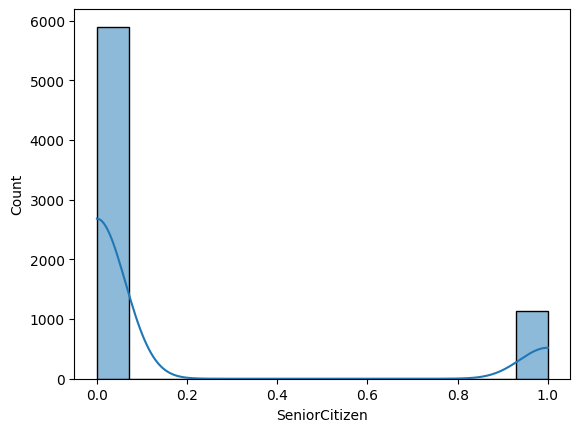

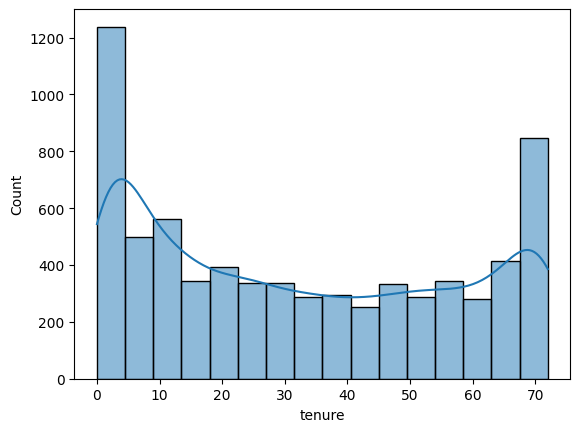

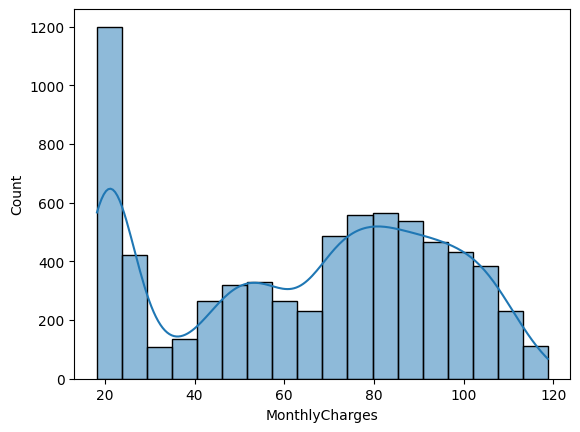

In [13]:
for i in num_col:
    sns.histplot(telco[i],kde=True)
    plt.show()

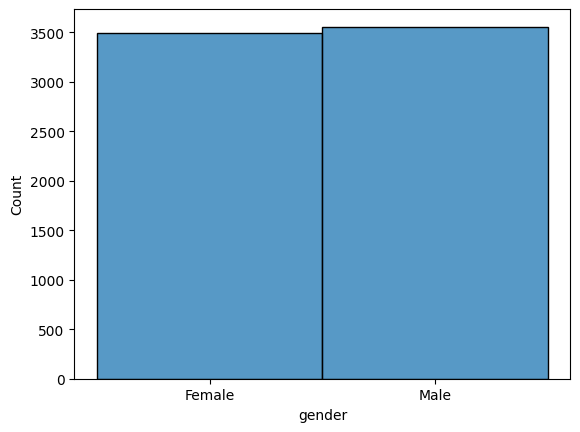

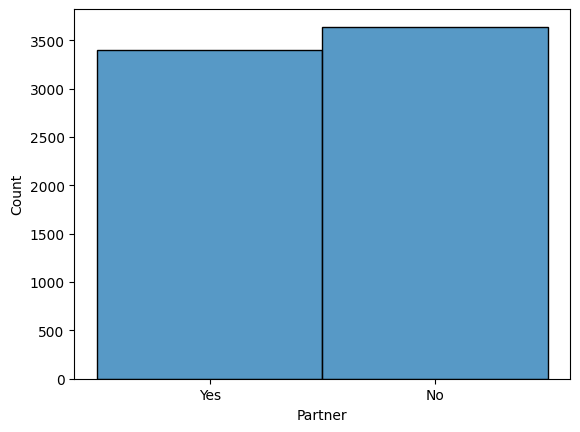

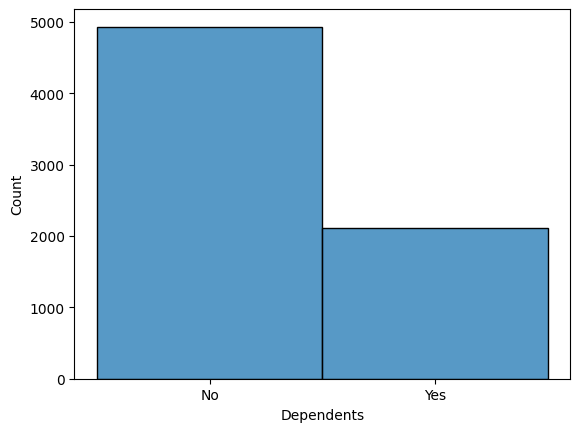

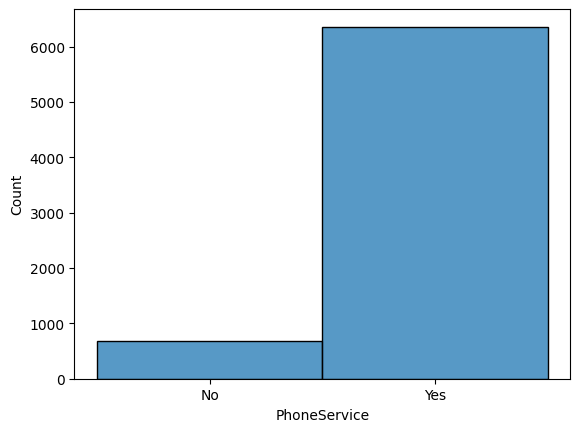

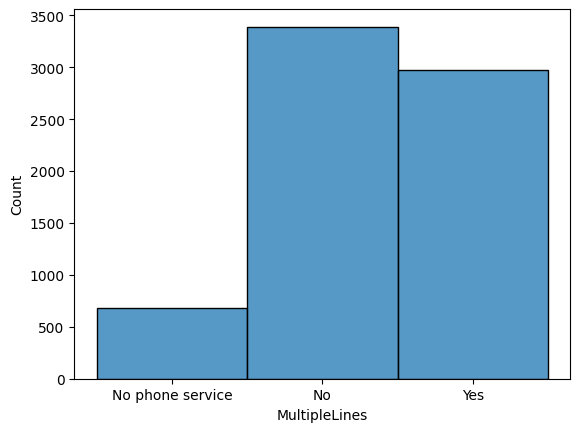

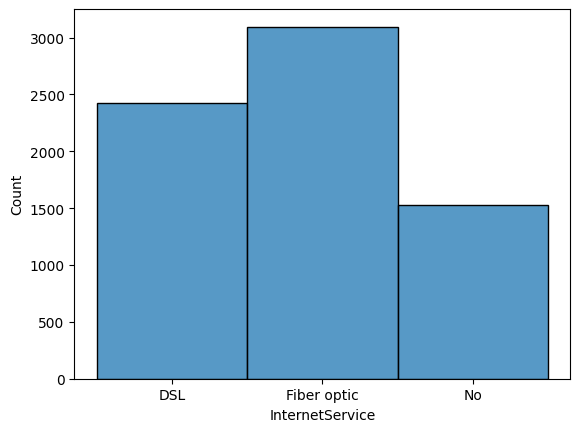

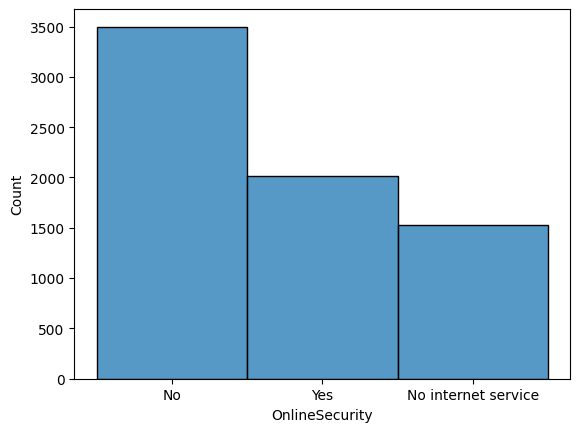

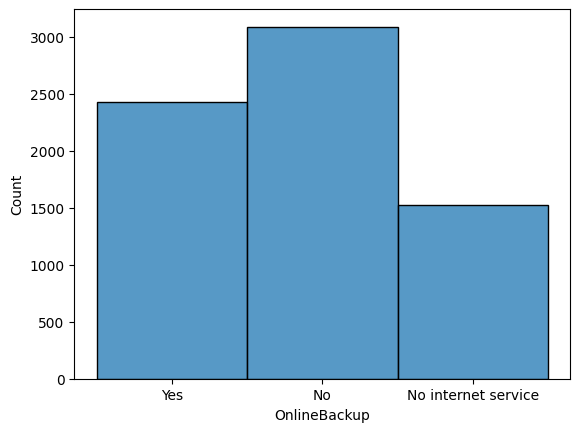

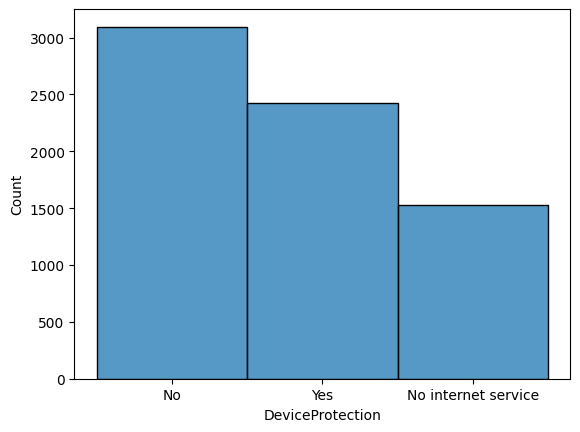

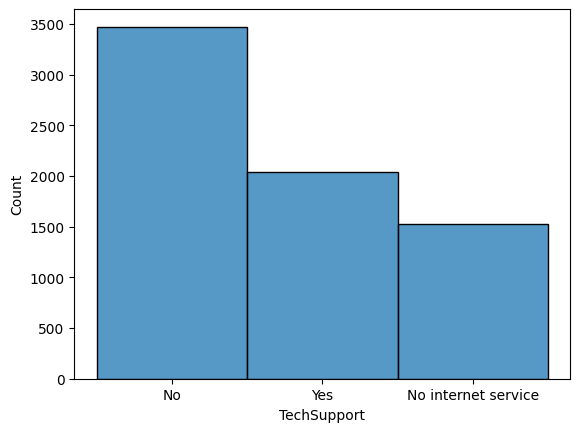

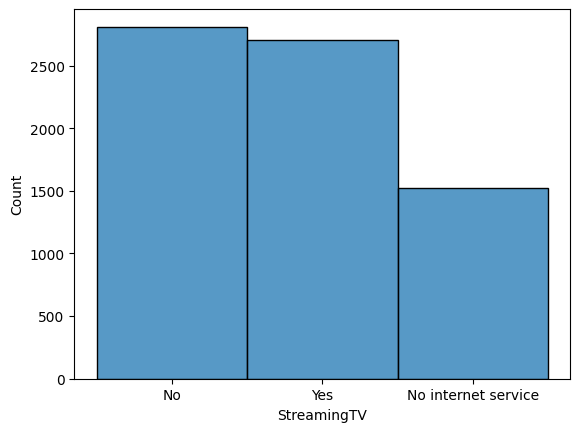

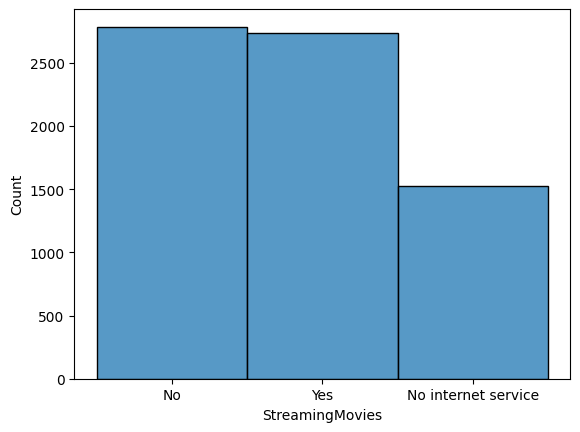

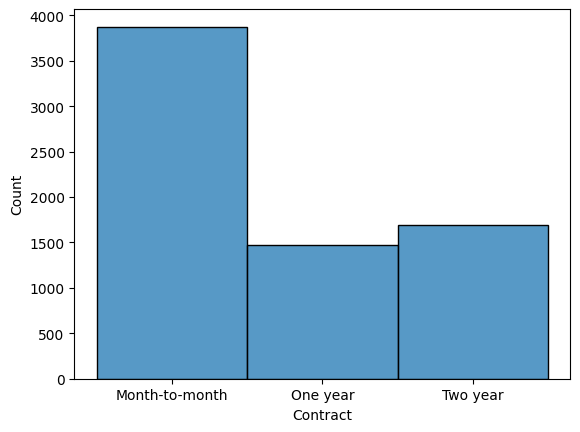

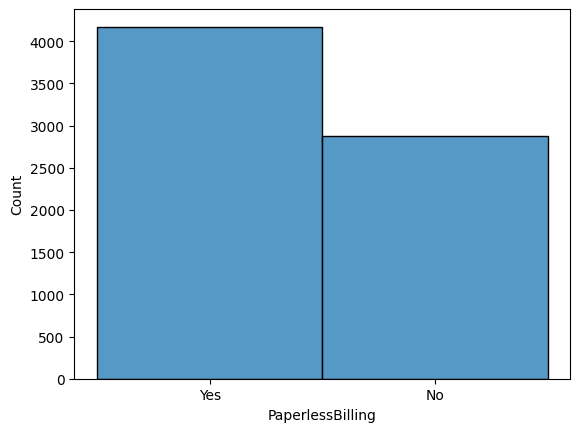

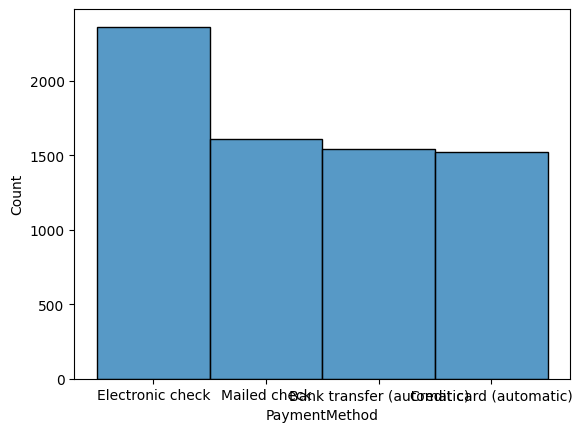

In [14]:
for i in cat_col:
    sns.histplot(telco[i])
    plt.show()

In [15]:
telco[num_col].skew()

,0
SeniorCitizen,1.833633
tenure,0.239540
MonthlyCharges,-0.220524


# **Data Split**

In [16]:
x_train,x_test,y_train,y_test=train_test_split(telco.drop(columns='Churn'),telco['Churn'],test_size=0.2,random_state=42)

# **PreProcessing**

In [17]:
num_col

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [18]:
cat_col

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [19]:
le=LabelEncoder()
y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)

In [20]:
pipe1=Pipeline([
    ('scaler',StandardScaler()),
    ('pt',PowerTransformer())
])
pipe2=Pipeline([
    ('imp',SimpleImputer()),
    ('scaler',StandardScaler()),
    ('pt',PowerTransformer())
])

In [21]:
trf=ColumnTransformer([
    ('imp',pipe2,['TotalCharges']),
    ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),cat_col),
    ('pipe',pipe1,num_col),
],remainder='passthrough')

In [22]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

# **Logistic Regression**

In [23]:
param_grid_lr={
    'C':[0.01,0.1,0.5,1],
    'l1_ratio':[0.01,0.1,0.5,1],
    'max_iter':[1000,10000],
    'solver':['saga']
}

In [24]:
grid_lr=GridSearchCV(
    LogisticRegression(),
    param_grid_lr,
    cv=5,
    verbose=3,
    scoring='f1',
    n_jobs=-1
)

In [25]:
grid_lr.fit(x_train_trf,y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 0.5, 1],
                         'l1_ratio': [0.01, 0.1, 0.5, 1],
                         'max_iter': [1000, 10000], 'solver': ['saga']},
             scoring='f1', verbose=3)

In [26]:
grid_lr.best_params_

{'C': 0.5, 'l1_ratio': 0.01, 'max_iter': 1000, 'solver': 'saga'}

In [27]:
grid_lr.best_score_

np.float64(0.5916746815465059)

In [28]:
y_pred_lr=grid_lr.predict(x_test_trf)

In [29]:
print(classification_report(y_pred_lr,y_test))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88      1095
           1       0.58      0.68      0.63       314

    accuracy                           0.82      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.83      0.82      0.82      1409



In [30]:
y_prob_lr=grid_lr.predict_proba(x_test_trf)[:,1]

**Threshold Tunning**

In [31]:
fpr,tpr,threshold=roc_curve(y_test,y_prob_lr)

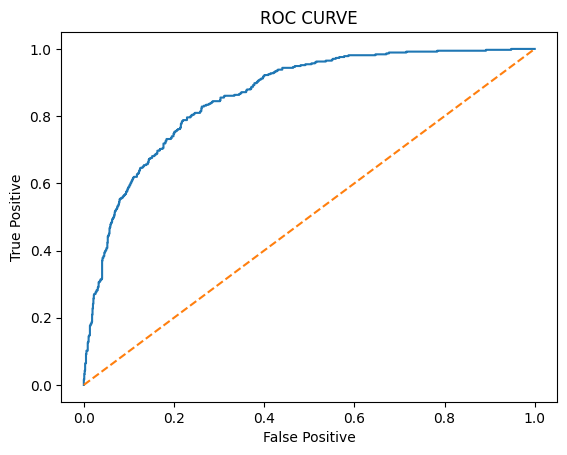

In [32]:
plt.plot(fpr,tpr)
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC CURVE')
plt.plot([0, 1], [0, 1], linestyle="--")

In [33]:
roc_auc_score(y_test,y_prob_lr)

np.float64(0.8617582059271066)

In [34]:
bt=threshold[np.argmax(tpr-fpr)]

In [35]:
y_prob_lr_t=(y_prob_lr>=bt).astype(int)

In [36]:
print(classification_report(y_test,y_prob_lr_t))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1036
           1       0.56      0.79      0.66       373

    accuracy                           0.78      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.78      0.79      1409



In [37]:
confusion_matrix(y_test,y_prob_lr_t)

array([[808, 228],
       [ 79, 294]])

# **KNN**

In [38]:
param_grid_knn={
    'n_neighbors':[5,10,15,20],
    'metric':['minkowski','manhattan','euclidean']
}

In [39]:
grid_knn=GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1',
    verbose=3,
    n_jobs=-1
)

In [40]:
grid_knn.fit(x_train_trf,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['minkowski', 'manhattan', 'euclidean'],
                         'n_neighbors': [5, 10, 15, 20]},
             scoring='f1', verbose=3)

In [41]:
grid_knn.best_score_

np.float64(0.5701603009370426)

In [42]:
grid_knn.best_params_

{'metric': 'manhattan', 'n_neighbors': 15}

In [43]:
y_pred_knn=grid_knn.predict(x_test_trf)

In [44]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1036
           1       0.64      0.57      0.60       373

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [45]:
confusion_matrix(y_test,y_pred_knn)

array([[915, 121],
       [159, 214]])

**Threshold Tunning**

In [46]:
y_prob_knn=grid_knn.predict_proba(x_test_trf)[:,1]

In [47]:
fpr,tpr,threshold=roc_curve(y_test,y_prob_knn)

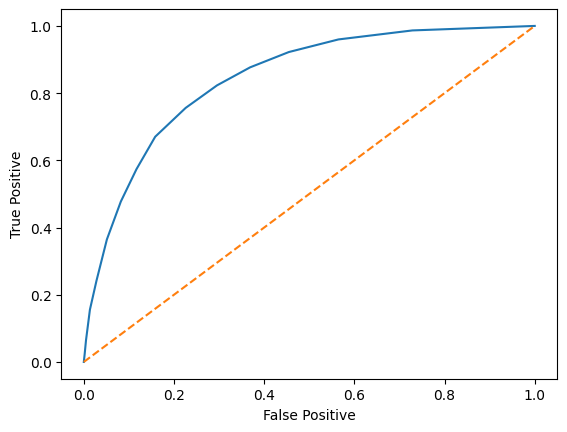

In [48]:
plt.plot(fpr,tpr)
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.plot([0, 1], [0, 1], linestyle='--')

In [49]:
roc_auc_score(y_test,y_prob_knn)

np.float64(0.8434054985663565)

In [50]:
bt=threshold[np.argmax(tpr-fpr)]

In [51]:
y_pred_knn_t=(y_pred_knn>=bt).astype(int)

In [52]:
print(classification_report(y_test,y_pred_knn_t))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1036
           1       0.64      0.57      0.60       373

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [53]:
confusion_matrix(y_test,y_pred_knn_t)

array([[915, 121],
       [159, 214]])

# **SVM**

In [54]:
param_grid_svm={
    'C':[0.01,0.1,0.3,0.5,0.8,1],
    'kernel':['linear','poly','rbf','sigmoid'],
    'degree':[1,2,3,4],
    'decision_function_shape':['ovo','ovr']
}

In [55]:
grid_svm=GridSearchCV(
    SVC(),
    param_grid_svm,
    verbose=1, cv=5, scoring='f1',n_jobs=-1
)

In [56]:
grid_svm.fit(x_train_trf,y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 0.3, 0.5, 0.8, 1],
                         'decision_function_shape': ['ovo', 'ovr'],
                         'degree': [1, 2, 3, 4],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='f1', verbose=1)

In [57]:
grid_svm.best_params_

{'C': 0.01, 'decision_function_shape': 'ovo', 'degree': 1, 'kernel': 'linear'}

In [58]:
grid_svm.best_score_

np.float64(0.5585365751288587)

In [59]:
y_pred_svm=grid_svm.predict(x_test_trf)

In [60]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1036
           1       0.71      0.55      0.62       373

    accuracy                           0.82      1409
   macro avg       0.78      0.73      0.75      1409
weighted avg       0.81      0.82      0.81      1409



**HyperParameter Tunning**

Since SVM donot use probability to predict therefore we use decision future which convert the decision score into probability

You can also use Probability=True in model to get probability

In [61]:
y_prob_svm=grid_svm.decision_function(x_test_trf)

In [62]:
fpr,tpr,threshold=roc_curve(y_test,y_prob_svm)

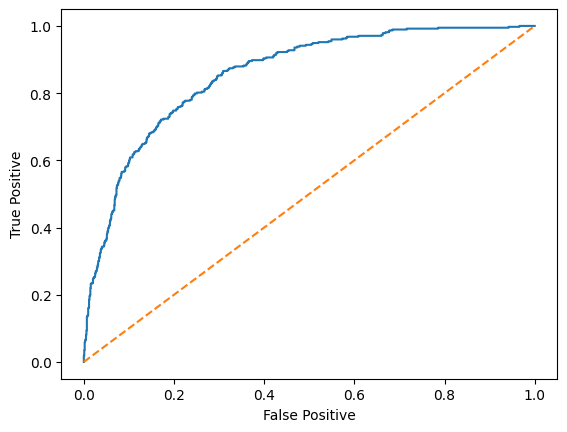

In [63]:
plt.plot(fpr,tpr)
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.plot([0,1],[0,1], linestyle='--')

In [64]:
bt=threshold[np.argmax(tpr-fpr)]

In [65]:
y_pred_svm_t=(y_prob_svm>=bt).astype(int)

In [66]:
print(classification_report(y_test,y_pred_svm_t))

              precision    recall  f1-score   support

           0       0.93      0.69      0.79      1036
           1       0.50      0.87      0.64       373

    accuracy                           0.74      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.74      0.75      1409



In [67]:
confusion_matrix(y_test,y_pred_svm_t)

array([[716, 320],
       [ 50, 323]])

# **Decision Tree**

In [68]:
param_grid_dt={
    'criterion':['gini','entropy','log_loss'],
    'max_depth':[2,5,7,9,12,15,18,20,25],
    'min_samples_split':[2,5,10,20,50,100],
    'min_samples_leaf':[1,2,5,10,20,50]
}

In [69]:
grid_dt=GridSearchCV(
    DecisionTreeClassifier(),
    param_grid_dt,
    verbose=1, cv=5, n_jobs=-1, scoring='f1'
)

In [70]:
grid_dt.fit(x_train_trf,y_train)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 5, 7, 9, 12, 15, 18, 20, 25],
                         'min_samples_leaf': [1, 2, 5, 10, 20, 50],
                         'min_samples_split': [2, 5, 10, 20, 50, 100]},
             scoring='f1', verbose=1)

In [71]:
grid_dt.best_params_

{'criterion': 'gini',
 'max_depth': 2,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [72]:
grid_dt.best_score_

np.float64(0.5794122887668973)

In [73]:
y_pred_dt=grid_dt.predict(x_test_trf)

In [74]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1036
           1       0.57      0.66      0.61       373

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [75]:
confusion_matrix(y_test,y_pred_dt)

array([[851, 185],
       [127, 246]])

**HyperParameter Tunning**

In [76]:
y_prob_dt=grid_dt.predict_proba(x_test_trf)[:,1]

In [77]:
fpr,tpr,threshold=roc_curve(y_test,y_prob_dt)

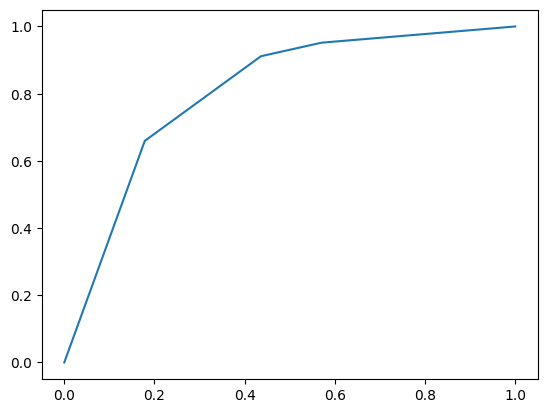

In [78]:
plt.plot(fpr,tpr)

In [79]:
bt=threshold[np.argmax(tpr-fpr)]

In [80]:
y_pred_dt_t=(y_prob_dt>=bt).astype(int)

In [81]:
print(classification_report(y_test,y_pred_dt_t))

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1036
           1       0.57      0.66      0.61       373

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [82]:
confusion_matrix(y_test,y_pred_dt_t)

array([[851, 185],
       [127, 246]])

# **Random Forest**

In [83]:
def objective(trial):
  params_rf={
      'n_estimators': trial.suggest_int('n_estimators',100,500),

      'criterion': trial.suggest_categorical('criterion',['gini','entropy','log_loss']),

      'max_depth': trial.suggest_int('max_depth',5,30),

      'class_weight':trial.suggest_categorical('class_weight',['balanced','balanced_subsample',None]),
      'min_samples_split':trial.suggest_int('min_samples_split',2,15),
      'min_samples_leaf':trial.suggest_int('min_samples_leaf',1,13),
      'max_features':trial.suggest_categorical('max_features',['sqrt','log2']),
      'bootstrap':trial.suggest_categorical('bootstrap',[True,False])
  }
  rf=RandomForestClassifier(
      **params_rf,random_state=42,n_jobs=-1
  )

  score=cross_val_score(rf,x_train_trf,y_train,cv=5,scoring='f1',n_jobs=-1)

  return score.mean()

In [84]:
study=optuna.create_study(direction='maximize')

study.optimize(objective,n_trials=100)

[I 2026-08-31 14:25:56,068] A new study created in memory with name: no-name-fac74b5d-3e1e-4838-8c98-03c5e3668763
[I 2026-08-31 14:26:07,980] Trial 0 finished with value: 0.6253836826864011 and parameters: {'n_estimators': 439, 'criterion': 'gini', 'max_depth': 13, 'class_weight': 'balanced', 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.6253836826864011.
[I 2026-08-31 14:26:19,017] Trial 1 finished with value: 0.6279465685437606 and parameters: {'n_estimators': 444, 'criterion': 'log_loss', 'max_depth': 8, 'class_weight': 'balanced', 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 0.6279465685437606.
[I 2026-08-31 14:26:33,366] Trial 2 finished with value: 0.6199126306409171 and parameters: {'n_estimators': 406, 'criterion': 'gini', 'max_depth': 29, 'class_weight': 'balanced_subsample', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_

In [85]:
print("Best F1:", study.best_value)
print("Best parameters:", study.best_params)

Best F1: 0.635002298124482
Best parameters: {'n_estimators': 156, 'criterion': 'gini', 'max_depth': 9, 'class_weight': 'balanced_subsample', 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}


In [86]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
)

plot_optimization_history(study).show()

plot_param_importances(study).show()

plot_slice(study).show()

In [87]:
best_rf=RandomForestClassifier(
    **study.best_params,random_state=42,n_jobs=-1
)

In [88]:
best_rf.fit(x_train_trf,y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=9,
                       min_samples_leaf=4, min_samples_split=13,
                       n_estimators=156, n_jobs=-1, random_state=42)

In [89]:
y_pred_rf=best_rf.predict(x_test_trf)

In [90]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.76      0.83      1036
           1       0.55      0.81      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



In [91]:
confusion_matrix(y_test,y_pred_rf)

array([[787, 249],
       [ 72, 301]])

**Threshold Tunning**

In [92]:
y_prob_rf=best_rf.predict_proba(x_test_trf)[:,1]

In [93]:
fpr,tpr,threshold=roc_curve(y_test,y_prob_rf)

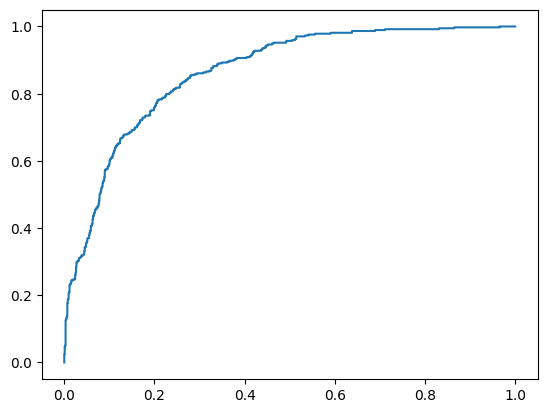

In [94]:
plt.plot(fpr,tpr)

In [95]:
roc_auc_score(y_test,y_prob_rf)

np.float64(0.8641467492003685)

In [96]:
bt=threshold[np.argmax(tpr-fpr)]

In [97]:
y_pred_rf_t=(y_prob_rf>=bt).astype(int)

In [98]:
print(classification_report(y_test,y_pred_rf_t))

              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.86      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.79      0.73      1409
weighted avg       0.82      0.76      0.77      1409



In [99]:
confusion_matrix(y_test,y_pred_rf_t)

array([[745, 291],
       [ 54, 319]])

# **AdaBoost**

In [100]:
def objective(trial):
  param_ada={
      'n_estimators':trial.suggest_int('n_estimators',50,500),
      'learning_rate':trial.suggest_float('learning_rate',0.001,1)
  }
  ada=AdaBoostClassifier(**param_ada,random_state=42)

  score=cross_val_score(ada,x_train_trf,y_train,cv=5,scoring='f1',n_jobs=-1)
  return score.mean()

In [101]:
study=optuna.create_study(direction='maximize')

study.optimize(objective,n_trials=100)

[I 2026-08-31 14:40:18,513] A new study created in memory with name: no-name-b6e42511-260b-445d-aba8-ed3e8ee16cb7
[I 2026-08-31 14:40:25,714] Trial 0 finished with value: 0.5246760920309136 and parameters: {'n_estimators': 183, 'learning_rate': 0.11298700699872692}. Best is trial 0 with value: 0.5246760920309136.
[I 2026-08-31 14:40:27,835] Trial 1 finished with value: 0.5682749440672128 and parameters: {'n_estimators': 64, 'learning_rate': 0.6232160956821639}. Best is trial 1 with value: 0.5682749440672128.
[I 2026-08-31 14:40:40,989] Trial 2 finished with value: 0.5794217837874842 and parameters: {'n_estimators': 387, 'learning_rate': 0.5158608959327038}. Best is trial 2 with value: 0.5794217837874842.
[I 2026-08-31 14:40:44,747] Trial 3 finished with value: 0.5759861814415059 and parameters: {'n_estimators': 121, 'learning_rate': 0.866266068617009}. Best is trial 2 with value: 0.5794217837874842.
[I 2026-08-31 14:40:47,304] Trial 4 finished with value: 0.5619530932188713 and paramet

In [102]:
print("Best F1:", study.best_value)
print("Best parameters:", study.best_params)

Best F1: 0.5857035339849023
Best parameters: {'n_estimators': 55, 'learning_rate': 0.8020931255912925}


In [103]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
)

plot_optimization_history(study).show()

plot_param_importances(study).show()

plot_slice(study).show()

In [104]:
best_ada=AdaBoostClassifier(**study.best_params,random_state=42)

In [105]:
best_ada.fit(x_train_trf,y_train)

AdaBoostClassifier(learning_rate=0.8020931255912925, n_estimators=55,
                   random_state=42)

In [106]:
y_pred_ada=best_ada.predict(x_test_trf)

In [107]:
print(classification_report(y_test,y_pred_ada))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.66      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [108]:
confusion_matrix(y_test,y_pred_ada)

array([[930, 106],
       [163, 210]])

**Threshold Tunning**

In [109]:
y_prob_ada=best_ada.predict_proba(x_test_trf)[:,1]

In [110]:
fpr,tpr,threshold=roc_curve(y_test,y_prob_ada)

In [111]:
bt=threshold[np.argmax(tpr-fpr)]

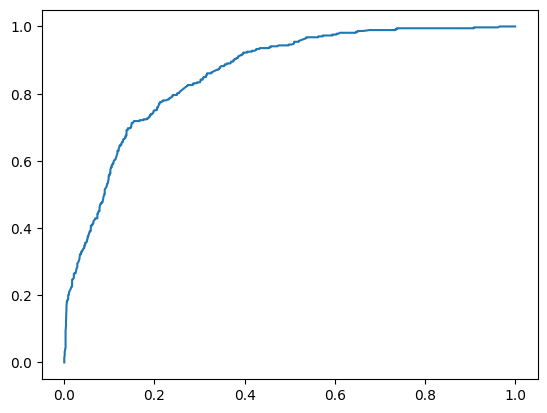

In [112]:
plt.plot(fpr,tpr)

In [113]:
roc_auc_score(y_test,y_prob_ada)

np.float64(0.8590332481083152)

In [114]:
y_pred_ada_t=(y_prob_ada>=bt).astype(int)

In [115]:
print(classification_report(y_test,y_pred_ada_t))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1036
           1       0.63      0.72      0.67       373

    accuracy                           0.81      1409
   macro avg       0.76      0.78      0.77      1409
weighted avg       0.82      0.81      0.82      1409



In [116]:
confusion_matrix(y_test,y_pred_ada_t)

array([[876, 160],
       [105, 268]])

# **Gradeint Boosting**

In [117]:
def objective(trial):
  param_grid={
      'loss':trial.suggest_categorical('loss',['log_loss','exponential']),
      'learning_rate':trial.suggest_float('learning_rate',0.0001,1),
      'n_estimators':trial.suggest_int('n_estimators',100,500),
      'max_depth':trial.suggest_int('max_depth',2,15),
      'min_samples_split':trial.suggest_int('min_samples_split',2,20),
      'min_samples_leaf':trial.suggest_int('min_samples_leaf',1,15),
      'subsample':trial.suggest_float('subsample',0.6,1),
      'max_features':trial.suggest_categorical('max_features',[None,'sqrt','log2'])
  }
  gb=GradientBoostingClassifier(**param_grid,random_state=42)
  score=cross_val_score(gb,x_train_trf,y_train,cv=5,scoring='f1')
  return score.mean()

In [120]:
study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=100)

[I 2026-08-31 14:59:18,678] A new study created in memory with name: no-name-e2ebe265-14a4-4a0a-92cd-b6627dca7430
[I 2026-08-31 14:59:51,183] Trial 0 finished with value: 0.48508177897049176 and parameters: {'loss': 'log_loss', 'learning_rate': 0.6864687441905141, 'n_estimators': 423, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 10, 'subsample': 0.7302224920077274, 'max_features': 'log2'}. Best is trial 0 with value: 0.48508177897049176.
[I 2026-08-31 15:00:17,583] Trial 1 finished with value: 0.5250005720482348 and parameters: {'loss': 'exponential', 'learning_rate': 0.8330762155849815, 'n_estimators': 396, 'max_depth': 3, 'min_samples_split': 12, 'min_samples_leaf': 10, 'subsample': 0.8892264951421335, 'max_features': None}. Best is trial 1 with value: 0.5250005720482348.
[I 2026-08-31 15:01:02,259] Trial 2 finished with value: 0.43979654823573283 and parameters: {'loss': 'log_loss', 'learning_rate': 0.5422425839769667, 'n_estimators': 443, 'max_depth': 10, 'min_sampl

In [121]:
print('Best F1 score',study.best_value)
print('Best Parameter',study.best_params)

Best F1 score 0.5875990917247661
Best Parameter {'loss': 'log_loss', 'learning_rate': 0.145416251050418, 'n_estimators': 100, 'max_depth': 2, 'min_samples_split': 19, 'min_samples_leaf': 1, 'subsample': 0.6205147469986381, 'max_features': None}


In [122]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
)

plot_optimization_history(study).show()

plot_param_importances(study).show()

plot_slice(study).show()

In [123]:
best_gb=GradientBoostingClassifier(**study.best_params,random_state=42)

In [124]:
best_gb.fit(x_train_trf,y_train)

GradientBoostingClassifier(learning_rate=0.145416251050418, max_depth=2,
                           min_samples_split=19, random_state=42,
                           subsample=0.6205147469986381)

In [126]:
y_pred_gb=best_gb.predict(x_test_trf)

In [127]:
print(classification_report(y_test,y_pred_gb))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [128]:
confusion_matrix(y_test,y_pred_gb)

array([[936, 100],
       [164, 209]])

# **XGBoost**

In [146]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1,10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'reg_alpha': trial.suggest_float(
            'reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10, log=True),
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    model = XGBClassifier(**params)
    score = cross_val_score(
        model,x_train_trf,y_train,cv=5,scoring='f1',
        n_jobs=-1
    ).mean()

    return score

In [147]:
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=100)

[I 2026-08-31 15:20:12,779] A new study created in memory with name: no-name-fcc30d2c-4a7e-421f-9cc7-2d2026310a3f
[I 2026-08-31 15:20:15,693] Trial 0 finished with value: 0.5755773357716322 and parameters: {'n_estimators': 927, 'learning_rate': 0.14232889423528308, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.926448562078166, 'colsample_bytree': 0.9161432322084909, 'gamma': 1.2124743668163396, 'reg_alpha': 0.0011498642720762784, 'reg_lambda': 2.415240557490833}. Best is trial 0 with value: 0.5755773357716322.
[I 2026-08-31 15:20:19,875] Trial 1 finished with value: 0.5455553202154226 and parameters: {'n_estimators': 828, 'learning_rate': 0.2533334600807312, 'max_depth': 3, 'min_child_weight': 6, 'subsample': 0.9009366867842723, 'colsample_bytree': 0.9404096821111143, 'gamma': 0.16216308461495021, 'reg_alpha': 2.106668060941114, 'reg_lambda': 0.30497211459312096}. Best is trial 0 with value: 0.5755773357716322.
[I 2026-08-31 15:20:21,547] Trial 2 finished with value: 0.58231580

In [148]:
print(study.best_params)
print(study.best_value)

{'n_estimators': 615, 'learning_rate': 0.03640909572458532, 'max_depth': 8, 'min_child_weight': 9, 'subsample': 0.5067492198144757, 'colsample_bytree': 0.9827055976492953, 'gamma': 5.108198093314192, 'reg_alpha': 6.621936332239856e-06, 'reg_lambda': 8.660949128822976}
0.5981504304236438


In [149]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
)

plot_optimization_history(study).show()

plot_param_importances(study).show()

plot_slice(study).show()

In [150]:
xg=XGBClassifier(**study.best_params)

In [151]:
xg.fit(x_train_trf,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9827055976492953, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=5.108198093314192, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03640909572458532,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=615, n_jobs=None,
              num_parallel_tree=None, ...)

In [152]:
y_pred_xg=xg.predict(x_test_trf)

In [153]:
print(classification_report(y_test,y_pred_xg))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [154]:
confusion_matrix(y_test,y_pred_xg)

array([[937,  99],
       [159, 214]])

# **Bagging**

In [158]:
def objective(trial):
    # Base Decision Tree
    dt = DecisionTreeClassifier(
        max_depth=trial.suggest_int('max_depth', 2, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        criterion=trial.suggest_categorical(
            'criterion',
            ['gini', 'entropy', 'log_loss']
        ),
        random_state=42
    )

    # Bagging
    bag = BaggingClassifier(
        estimator=dt,
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_samples=trial.suggest_float('max_samples', 0.5, 1.0),
        max_features=trial.suggest_float('max_features', 0.5, 1.0),
        bootstrap=trial.suggest_categorical(
            'bootstrap',
            [True, False]
        ),
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        bag,
        x_train_trf,
        y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    ).mean()

    return score

In [159]:
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=100)

[I 2026-08-31 15:25:34,281] A new study created in memory with name: no-name-c08474ab-c8e2-4c54-b289-7c952f9e51e4
[I 2026-08-31 15:25:47,584] Trial 0 finished with value: 0.7887822083810743 and parameters: {'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 10, 'criterion': 'entropy', 'n_estimators': 236, 'max_samples': 0.711834091950245, 'max_features': 0.8929524755498403, 'bootstrap': False}. Best is trial 0 with value: 0.7887822083810743.
[I 2026-08-31 15:26:05,565] Trial 1 finished with value: 0.80067423061587 and parameters: {'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 5, 'criterion': 'entropy', 'n_estimators': 219, 'max_samples': 0.7354066252345963, 'max_features': 0.950877032958797, 'bootstrap': True}. Best is trial 1 with value: 0.80067423061587.
[I 2026-08-31 15:26:14,935] Trial 2 finished with value: 0.7884279142192053 and parameters: {'max_depth': 3, 'min_samples_split': 14, 'min_samples_leaf': 1, 'criterion': 'log_loss', 'n_estimators': 238, 'max_s

In [161]:
print(study.best_params)
print(study.best_value)

{'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 2, 'criterion': 'log_loss', 'n_estimators': 204, 'max_samples': 0.6587507918751404, 'max_features': 0.5359189505722476, 'bootstrap': False}
0.8049347439956753


In [162]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
)

plot_optimization_history(study).show()

plot_param_importances(study).show()

plot_slice(study).show()

In [164]:
best_params = study.best_params

dt = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    criterion=best_params['criterion'],
    random_state=42
)

bag = BaggingClassifier(
    estimator=dt,
    n_estimators=best_params['n_estimators'],
    random_state=42,
    n_jobs=-1
)

In [165]:
bag.fit(x_train_trf,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(criterion='log_loss',
                                                   max_depth=7,
                                                   min_samples_leaf=2,
                                                   min_samples_split=7,
                                                   random_state=42),
                  n_estimators=204, n_jobs=-1, random_state=42)

In [167]:
y_pred_bag=bag.predict(x_test_trf)

In [168]:
print(classification_report(y_test,y_pred_bag))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1036
           1       0.69      0.53      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [169]:
confusion_matrix(y_test,y_pred_bag)

array([[946,  90],
       [175, 198]])

# **Voting Classifier**

In [170]:
def objective(trial):
    lr = LogisticRegression(
        C=trial.suggest_float('lr_C', 0.01, 10, log=True),
        max_iter=1000
    )

    dt = DecisionTreeClassifier(
        max_depth=trial.suggest_int('dt_max_depth', 2, 20),
        min_samples_split=trial.suggest_int(
            'dt_min_samples_split', 2, 20
        ),
        min_samples_leaf=trial.suggest_int(
            'dt_min_samples_leaf', 1, 10
        ),
        criterion=trial.suggest_categorical(
            'dt_criterion',
            ['gini', 'entropy', 'log_loss']
        ),
        random_state=42
    )

    svm = SVC(
        C=trial.suggest_float('svm_C', 0.01, 10, log=True),
        kernel=trial.suggest_categorical(
            'svm_kernel',
            ['linear', 'rbf', 'poly']
        ),
        gamma=trial.suggest_categorical(
            'svm_gamma',
            ['scale', 'auto']
        ),
        probability=True
    )

    voting = VotingClassifier(
        estimators=[
            ('lr', lr),
            ('dt', dt),
            ('svm', svm)
        ],
        voting='soft'
    )

    score = cross_val_score(
        voting,
        x_train_trf,
        y_train,
        cv=5,
        scoring='f1',
        n_jobs=-1
    ).mean()

    return score


In [171]:
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=100)

[I 2026-08-31 15:49:20,787] A new study created in memory with name: no-name-fc512db9-bd0f-4421-a28f-ecbc6e93e402
[I 2026-08-31 15:49:40,984] Trial 0 finished with value: 0.5428583710699675 and parameters: {'lr_C': 5.27479792293326, 'dt_max_depth': 16, 'dt_min_samples_split': 18, 'dt_min_samples_leaf': 3, 'dt_criterion': 'log_loss', 'svm_C': 3.357208860326105, 'svm_kernel': 'poly', 'svm_gamma': 'auto'}. Best is trial 0 with value: 0.5428583710699675.
[I 2026-08-31 15:50:04,478] Trial 1 finished with value: 0.5675947227708318 and parameters: {'lr_C': 0.017843840550636644, 'dt_max_depth': 20, 'dt_min_samples_split': 20, 'dt_min_samples_leaf': 6, 'dt_criterion': 'log_loss', 'svm_C': 0.018761237108601704, 'svm_kernel': 'poly', 'svm_gamma': 'auto'}. Best is trial 1 with value: 0.5675947227708318.
[I 2026-08-31 15:50:30,672] Trial 2 finished with value: 0.5492288177877436 and parameters: {'lr_C': 0.1752565399979317, 'dt_max_depth': 15, 'dt_min_samples_split': 4, 'dt_min_samples_leaf': 2, 'dt

In [173]:
print("Best Parameters:",study.best_params)

print("Best CV Score:",study.best_value)

Best Parameters: {'lr_C': 0.2013176219605924, 'dt_max_depth': 5, 'dt_min_samples_split': 7, 'dt_min_samples_leaf': 6, 'dt_criterion': 'entropy', 'svm_C': 0.03641709985474169, 'svm_kernel': 'rbf', 'svm_gamma': 'auto'}
Best CV Score: 0.5914617009147038


In [174]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
)

plot_optimization_history(study).show()

plot_param_importances(study).show()

plot_slice(study).show()

In [175]:
best = study.best_params

lr = LogisticRegression(
    C=best['lr_C'],
    max_iter=1000
)

dt = DecisionTreeClassifier(
    max_depth=best['dt_max_depth'],
    min_samples_split=best['dt_min_samples_split'],
    min_samples_leaf=best['dt_min_samples_leaf'],
    criterion=best['dt_criterion'],
    random_state=42
)

svm = SVC(
    C=best['svm_C'],
    kernel=best['svm_kernel'],
    gamma=best['svm_gamma'],
    probability=True
)
voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('svm', svm)
    ],
    voting='soft'
)

In [176]:
voting.fit(x_train_trf, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=0.2013176219605924,
                                                 max_iter=1000)),
                             ('dt',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=5,
                                                     min_samples_leaf=6,
                                                     min_samples_split=7,
                                                     random_state=42)),
                             ('svm',
                              SVC(C=0.03641709985474169, gamma='auto',
                                  probability=True))],
                 voting='soft')

In [178]:
y_pred_vote = voting.predict(x_test_trf)

In [179]:
print(classification_report(y_test,y_pred_vote))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [180]:
confusion_matrix(y_test,y_pred_vote)

array([[932, 104],
       [156, 217]])